# 1. Import & Config

In [21]:
import sys, os, json
import math
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
import numpy as np
import pandas as pd
from math import prod
from pathlib import Path
from dataclasses import fields, replace
from tqdm.asyncio import tqdm
from torch.utils.data import DataLoader
from scipy.stats import gaussian_kde

from config import (
    ExperimentConfig,
    DDPMTransformerConfig,
    InferenceConfig,
    ModelParamsSource,
    FMConfig,
    InjectionConfig,
)
from engine import Engine
from models import Diffusion, DiffusionTransformer, FlowMatchingModel
from utils import (
    setup_logging,
    setup_random_seed,
    load_variant,
    make_all_dataloaders,
    inverse_x,
    inverse_price,
)
from utils.paths import PROCESSED_DIR, EXPERIMENTS_DIR

logger = setup_logging()
logger.info("✓ Imports OK")

2026-06-07 18:20:02,655 - utils.setup - INFO - Logger is set up.
2026-06-07 18:20:02,657 - utils.setup - INFO - ✓ Imports OK


## 1.1. UI

In [ ]:

injection = InjectionConfig(
    feat_names = [
        "ATR",        # f=0
        "BB_lower",   # f=1
        "BB_mid",     # f=2  ← PC1 top
        "BB_upper",   # f=3
        "MACD",       # f=4
        "MACD_hist",  # f=5  ← PC1 #2
        "MACD_sig",   # f=6
        "ROC",        # f=7
        "RSI",        # f=8
    ],
    scenarios = [
        ("f=2 BB_mid",          [2]),
        ("f=5 MACD_hist",       [5]),
        ("f=8 RSI",             [8]),
        ("f=0 ATR",             [0]),
        ("f=7 ROC",             [7]),
        ("f=1,2,3 all_BBANDS",  [1, 2, 3]),
        ("f=4,5,6 all_MACD",    [4, 5, 6]),
        ("f=0..8 ALL",          list(range(9))),
    ],
    values = [
        -5000, 10000
    ],
    cond_window_shift = [1, 2, 3, 5]
)

inf_cfg = InferenceConfig(
    name              = "v3_inferencing_01",
    group             = "",
    description       = "Method 2 — independent window simulation",

    device      = "cuda:1",
    # ── paths ─────────────────────────────────────────────────
    processed_dir     = Path(PROCESSED_DIR),
    experiments_dir   = Path(EXPERIMENTS_DIR),

    # ── experiment to load ────────────────────────────────────
    experiment_name   = "v1_trial04_ddpm_warmup-cosine_w30_d20_seqWA_featDC_robust_standard",
    simulation_name   = "n100_simulations_independent_windows_rand72",
    # checkpoint_file   = "best_model.pt",
    checkpoint_file   = "epoch_1000.pt",

    # ── simulation ────────────────────────────────────────────
    num_simulations   = 100,
    random_seed       = 72,

)
skip_injection = True
X_DIMS = ('B', 'A', 'W', 'D', 'C')
COND_DIMS = ('B', 'A', 'W', 'C')

setup_random_seed(inf_cfg.random_seed)

In [23]:
print("=" * 60)
print("  V3-3 INFERENCING")
print("=" * 60)
print(f"  Config name     : {inf_cfg.name}")
print(f"  Description     : {inf_cfg.description}")
print(f"  Experiment      : {inf_cfg.experiment_name}")
print(f"  Experiment dir  : {inf_cfg.experiment_dir}")
print(f"  Checkpoint      : {inf_cfg.checkpoint_file}")
print(f"  Feature store   : {inf_cfg.load_feature_store_info()}")
print(f"  Num simulations : {inf_cfg.num_simulations}")
print(f"  Simulation dir  : {inf_cfg.simulation_dir}")
print(f"  Device          : {inf_cfg.device}")
print(f"  Random seed     : {inf_cfg.random_seed}")
print("=" * 60)

  V3-3 INFERENCING
  Config name     : v3_inferencing_01
  Description     : Method 2 — independent window simulation
  Experiment      : v1_trial04_ddpm_warmup-cosine_w20_d20_seqWA_featDC_robust_standard
  Experiment dir  : /home/narodom.y@FUSION.LAB/research/02_experiments/v1_trial04_ddpm_warmup-cosine_w20_d20_seqWA_featDC_robust_standard
  Checkpoint      : epoch_1000.pt
  Feature store   : ('v1_trial04_w20_d20_asset16', 'robust_standard')
  Num simulations : 2
  Simulation dir  : /home/narodom.y@FUSION.LAB/research/02_experiments/v1_trial04_ddpm_warmup-cosine_w20_d20_seqWA_featDC_robust_standard/simulations/beta_n100_simulations_independent_windows_rand72
  Device          : cuda:0
  Random seed     : 72


# 2. Load Feature Store & Model

## 2.1 Load feature store

In [24]:
feature_name, feature_variant = inf_cfg.load_feature_store_info()
batch_sizes = inf_cfg.load_batch_sizes()

data, scalers = load_variant(
    inf_cfg.processed_dir,
    feature_name,
    feature_variant,
)
loaders = make_all_dataloaders(
    inf_cfg.processed_dir,
    feature_name,
    feature_variant,
    batch_sizes=batch_sizes,
)

with open(inf_cfg.processed_dir / f"{feature_name}_{feature_variant}" / "meta.json") as f:
    meta = json.load(f)

SYMBOLS    = meta["cfg"]["symbols"]
x_scaler   = scalers["x"]
cond_scaler = scalers["cond"]

print("✓ Feature store loaded")

✓ Feature store loaded


## 2.2 Shape summary

In [25]:
for split in ["train", "val", "test"]:
    x    = data[split]["x"]
    cond = data[split]["cond"]
    print(f"  {split:<6}  x={str(x.shape):<28} cond={str(cond.shape):<22} n_windows={x.shape[0]}")

  train   x=(1341, 16, 20, 20, 4)        cond=(1341, 16, 20, 11)     n_windows=1341
  val     x=(934, 16, 20, 20, 4)         cond=(934, 16, 20, 11)      n_windows=934
  test    x=(46, 16, 20, 20, 4)          cond=(46, 16, 20, 11)       n_windows=46


## 2.3 Load model params & build model

In [26]:
def build_model(inf_cfg, data):
    data_config  = inf_cfg.load_data_config()
    model_params = inf_cfg.load_model_params()

    B, A, W, D, C = data["train"]["x"].shape
    _, _, _, F    = data["train"]["cond"].shape

    x_dim_map    = {"A": A, "W": W, "D": D, "C": C}
    cond_dim_map = {"A": A, "W": W, "F": F}
    cond_feat_dims = [d for d in data_config.feat_dims if d in cond_dim_map]
    if "F" not in cond_feat_dims:
        cond_feat_dims += ["F"]

    input_dim = math.prod(x_dim_map[d] for d in data_config.feat_dims)
    cond_dim  = math.prod(cond_dim_map[d] for d in cond_feat_dims)

    print(f"  seq_dims   : {data_config.seq_dims}")
    print(f"  feat_dims  : {data_config.feat_dims}")
    print(f"  d_model    : {model_params.d_model}  layers={model_params.num_layers}  heads={model_params.num_attention_heads}  dropout={model_params.dropout}")
    print(f"  input_dim  : {input_dim}  ({' * '.join(str(x_dim_map[d]) for d in data_config.feat_dims)})")
    print(f"  cond_dim   : {cond_dim}")

    if isinstance(model_params, DDPMTransformerConfig):
        backbone = DiffusionTransformer(
            input_dim           = input_dim,
            cond_dim            = cond_dim,
            d_model             = model_params.d_model,
            num_layers          = model_params.num_layers,
            num_attention_heads = model_params.num_attention_heads,
            dim_feedforward     = model_params.dim_feedforward,
            dropout             = model_params.dropout,
        )
        model = Diffusion(
            model      = backbone,
            timesteps  = model_params.timesteps,
            beta_start = model_params.beta_start,
            beta_end   = model_params.beta_end,
        ).to(inf_cfg.device)

    elif isinstance(model_params, FMConfig):
        model = FlowMatchingModel(cfg=model_params).to(inf_cfg.device)

    else:
        raise ValueError(f"Unknown model config: {type(model_params)}")

    n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"\n  ✓ Model built  params={n_params:,}")
    return model


model = build_model(inf_cfg, data)

  seq_dims   : ('W', 'A')
  feat_dims  : ('D', 'C')
  d_model    : 1024  layers=3  heads=4  dropout=0.1
  input_dim  : 80  (20 * 4)
  cond_dim   : 11

  ✓ Model built  params=53,715,024


## 2.4 Load checkpoint

In [27]:
ckpt_path = inf_cfg.checkpoint_path
print(f"  Loading checkpoint: {ckpt_path}")

ckpt = torch.load(ckpt_path, map_location=inf_cfg.device)
model.load_state_dict(ckpt["model_state_dict"])
model.eval()

val_loss = ckpt.get("val_loss")
try:
	val_loss_str = f"{val_loss:.6f}"
except (TypeError, ValueError):
	val_loss_str = str(val_loss)

print(f"  ✓ Checkpoint loaded  (epoch={ckpt.get('epoch', '?')}  val_loss={val_loss_str})")

  Loading checkpoint: /home/narodom.y@FUSION.LAB/research/02_experiments/v1_trial04_ddpm_warmup-cosine_w20_d20_seqWA_featDC_robust_standard/checkpoints/epoch_1000.pt


/tmp/ipykernel_76005/3747503523.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(ckpt_path, map_location=inf_cfg.device)


  ✓ Checkpoint loaded  (epoch=1000  val_loss=0.162766)


# 3. Simulate

## 3.1. Model Wrapper

In [28]:
def map_dims(tensor, dim_names):
    assert tensor.dim() == len(dim_names)
    return {
        dim: {"idx": i, "size": tensor.shape[i]}
        for i, dim in enumerate(dim_names)
    }

def flatten_dims(tensor, idxs):
    return prod(tensor.shape[i] for i in idxs)

def idxs_of(dim_map, dims):
    return [dim_map[d]['idx'] for d in dims if d in dim_map]

def model_shape(tensor, dims, seq_dims, feat_dims):
    dim_map    = map_dims(tensor, dims)
    batch_dims = tuple(d for d in dims if d not in seq_dims and d not in feat_dims)

    # sorted batch, seq, feat to reshape
    order = (idxs_of(dim_map, batch_dims) +
             idxs_of(dim_map, seq_dims) +
             idxs_of(dim_map, feat_dims))

    t = tensor.permute(order)
    return t.reshape(
        flatten_dims(tensor, idxs_of(dim_map, batch_dims)),
        flatten_dims(tensor, idxs_of(dim_map, seq_dims)),
        flatten_dims(tensor, idxs_of(dim_map, feat_dims)),
    )

def inverse_model_shape(tensor, tensor_original, dims, seq_dims, feat_dims):
    dim_map    = map_dims(tensor_original, dims)
    batch_dims = tuple(d for d in dims if d not in seq_dims and d not in feat_dims)

    # unflatten
    # batch_shape = [dim_map[d]['size'] for d in batch_dims]
    seq_shape   = [dim_map[d]['size'] for d in seq_dims]
    feat_shape  = [dim_map[d]['size'] for d in feat_dims]

    n_non_batch = int(np.prod(seq_shape)) * int(np.prod(feat_shape))
    n_batch     = tensor.numel() // n_non_batch

    t = tensor.reshape([n_batch] + seq_shape + feat_shape)

    # permute follow dims
    current = list(batch_dims) + list(seq_dims) + list(feat_dims)
    perm    = [current.index(d) for d in dims]
    return t.permute(perm)

In [29]:
def make_ddpm_sample_fn(model, data_cfg, cond_dims, x_dims, x_ref, device):
    x_flat = model_shape(
        x_ref,
        dims      = x_dims,
        seq_dims  = data_cfg.seq_dims,
        feat_dims = data_cfg.feat_dims
    ).to(device) # (B, Seq, Feat)

    def sample_fn(cond, n_sims=1):
        cond_flat = model_shape(
            cond,
            dims      = cond_dims,
            seq_dims  = data_cfg.seq_dims,
            feat_dims = data_cfg.feat_dims
        ).to(device) # (1, Seq, Feat)

        cond_in = cond_flat.expand(n_sims, -1, -1).contiguous() # (N sims, Seq, Feat)

        output_shape =  (n_sims, x_flat.shape[1], x_flat.shape[2]) # (N sims, Seq, Feat)
        x_gen = model.sample(x_cond=cond_in, output_shape=output_shape)

        # reshape back to x_dims
        target_shape = (n_sims,) + x_ref.shape[1:]

        return inverse_model_shape(
            x_gen,
            x_ref,
            dims=x_dims,
            seq_dims=data_cfg.seq_dims,
            feat_dims=data_cfg.feat_dims
        )

    return sample_fn

## 3.2. Simulate Functions

In [30]:
@torch.no_grad()
def simulate(
    sample_fn  : callable,          # make_ddpm_sample_fn(...) or make_new_model_sample_fn(...)
    cond       : torch.Tensor,      # [A, W, F]
) -> torch.Tensor:                  # [A, W, D, C]
    return sample_fn(cond, n_sims=1).squeeze(0)

@torch.no_grad()
def mc_simulate(
    sample_fn  : callable,
    cond       : torch.Tensor,      # [A, W, F]
    n_sims     : int,
) -> torch.Tensor:                  # [N, A, W, D, C]
    return sample_fn(cond, n_sims=n_sims)

@torch.no_grad()
def ar_simulate(
    sample_fn : callable,
    loader    : DataLoader,   # batch_size=1, shuffle=False
) -> list[dict]:
    results = []
    for batch in tqdm(loader, desc="AR Simulate"):
        _, cond, init_price, ohlcv, dates, init_date = batch

        cond_w       = cond.squeeze(0)        # [A, W, F]
        init_price_w = init_price.squeeze(0)  # [A]
        init_date_w  = init_date.squeeze(0)
        dates_w     = dates.squeeze(0)       # [W]
        ohlcv_w      = ohlcv.squeeze(0)      # [A, W, D, C]

        x_gen = sample_fn(cond_w, n_sims=1).squeeze(0)  # [A, W, (D,) C]

        results.append({
            "x_gen"      : x_gen.cpu(),
            "init_price" : init_price_w.cpu(),
            "init_date"  : init_date_w.cpu(),
            "dates"      : dates_w.cpu(),
            "ohlcv"      : ohlcv_w.cpu(),
        })

    return results

## 3.3 Inverse Scaled Functions

In [31]:
def decode_simulation(
    x_gen: torch.Tensor, # [N, A, W, C]  or  [N, A, W, D, C]
    x_scaler,
    init_price: torch.Tensor, # [A]
    idx_sequence: int = 0,
    idx_channel: int = 0,
):
    x_np = x_gen.cpu().numpy() # [N, A, W, (D,) C]

    # Reshape to 2D for inverse scaling: [N*A*W*(D,), C]
    original_shape = x_np.shape
    x_np_reshaped = x_np.reshape(-1, x_np.shape[-1])

    # Inverse scale → log returns
    log_returns = inverse_x(x_np_reshaped, x_scaler)

    # Reshape back to original dimensions
    log_returns = log_returns.reshape(original_shape)

    close_logret = log_returns[..., idx_sequence , idx_channel]

    # cumsum follows W axis to exp
    cum = np.cumsum(close_logret, axis=-1)
    init = init_price.cpu().numpy()

    # broadcast init_price: [..., A, 1]
    close_prices = init[..., np.newaxis] * np.exp(cum)
    return {
        "log_returns": log_returns,  # [N, A, W, (D,) C]
        "close_prices": close_prices,         # [..., A, W]
    }


In [32]:
def decode_date(date: torch.Tensor) -> np.datetime64:
    return date.cpu().numpy().astype("datetime64[ns]")

def decode_dates(dates: torch.Tensor) -> np.ndarray:
    return np.array([decode_date(d) for d in dates.flatten()])

# scaled log returns to unscaled log returns
def decode_to_log_returns(
    x: torch.Tensor,
    x_scaler,
):
    x_np = x.cpu().numpy()

    # Reshape to 2D for inverse scaling:
    original_shape = x_np.shape
    x_np_reshaped = x_np.reshape(-1, x_np.shape[-1])

    log_returns = inverse_x(x_np_reshaped, x_scaler)
    log_returns = log_returns.reshape(original_shape)

    return log_returns

def decode_to_prices(
    log_returns: np.ndarray,
    init_price,           # shape (1, 16)
    idx_channel: int = 0,
):
    log_returns_channel = log_returns[..., idx_channel]  # (1, 16, 20, 20)

    cum_log_returns = np.cumsum(log_returns_channel, axis=-1)  # cumsum ตาม pred axis

    # (1, 16) -> (1, 16, 1, 1) เพื่อ broadcast กับ (1, 16, 20, 20)
    init_price = np.array(init_price).reshape(1, 16, 1, 1)

    prices = init_price * np.exp(cum_log_returns)  # (1, 16, 20, 20)

    return prices

def decode(
    x: torch.Tensor,
    x_scaler,
    init_price: float,
    idx_channel: int = 0,
):
    log_returns = decode_to_log_returns(x, x_scaler)
    prices = decode_to_prices(log_returns, init_price, idx_channel)

    return log_returns, prices

In [33]:
def plot_log_return_dist(
    r_vals_flat: np.ndarray,
    g_vals_flat: np.ndarray,
    title: str = "",
    clip: float = 0.3,
    ax: plt.Axes | None = None,
) -> plt.Axes:
    xs = np.linspace(-clip, clip, 500)
    kde_r = gaussian_kde(r_vals_flat[np.abs(r_vals_flat) <= clip])(xs)
    kde_g = gaussian_kde(g_vals_flat[np.abs(g_vals_flat) <= clip])(xs)
    mu_r, mu_g = r_vals_flat.mean(), g_vals_flat.mean()

    if ax is None:
        _, ax = plt.subplots(figsize=(9, 6))  # <-- ใหญ่ขึ้น

    ax.fill_between(xs, kde_r, alpha=0.35, color="#1f77ff")
    ax.plot(xs, kde_r, color="#1f77ff", lw=2.5, label="real")

    ax.fill_between(xs, kde_g, alpha=0.30, color="#ff4422")
    ax.plot(xs, kde_g, color="#ff4422", lw=2.5, linestyle="--", label="gen")

    ax.axvline(mu_r, color="#1f77ff", lw=2.0, linestyle=":",
               label=f"μ_r={mu_r:.4f}")
    ax.axvline(mu_g, color="#ffaa00", lw=2.0, linestyle=":",
               label=f"μ_g={mu_g:.4f}")

    ax.set_xlim(-clip, clip)
    ax.set_xlabel("log-return", fontsize=13)
    ax.set_title(title, fontsize=14, fontweight="bold")
    ax.tick_params(labelsize=11)
    ax.legend(fontsize=11, framealpha=0.6, edgecolor="#cccccc")

    ax.set_facecolor("#f8f8f8")
    ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.5, color="#cccccc")
    ax.spines[["top", "right"]].set_visible(False)

    return ax

def plot_prices_comparison(
    prices_real: np.ndarray,   # (1, 16, 20, 20)
    prices_gen: np.ndarray,    # (1, 16, 20, 20)
    stock_names: list[str] | None = None,
    seq_idx: int = 0,
    ncols: int = 4,
):
    # (1, 16, 20, 20) -> (16, 20) เอา batch=0, seq=seq_idx
    r = prices_real[0, :, :, seq_idx]   # (16, 20)
    g = prices_gen[0, :, :, seq_idx]    # (16, 20)

    n_stocks = r.shape[0]
    nrows = math.ceil(n_stocks / ncols)

    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 5, nrows * 3.5))
    axes = axes.flatten()

    for i in range(n_stocks):
        ax = axes[i]
        name = stock_names[i] if stock_names else f"Stock {i}"

        ax.plot(r[i], color="#1f77ff", lw=2.0, label="real")
        ax.plot(g[i], color="#ff4422", lw=2.0, linestyle="--", label="gen")

        ax.set_title(name, fontsize=12, fontweight="bold")
        ax.set_xlabel("window step", fontsize=10)
        ax.set_ylabel("price", fontsize=10)
        ax.legend(fontsize=9, framealpha=0.6, edgecolor="#cccccc")
        ax.set_facecolor("#f8f8f8")
        ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.5, color="#cccccc")
        ax.spines[["top", "right"]].set_visible(False)

    # ซ่อน subplot ที่เกิน
    for j in range(n_stocks, len(axes)):
        axes[j].set_visible(False)

    fig.suptitle("Real vs Generated Prices", fontsize=15, fontweight="bold", y=1.01)
    plt.tight_layout()
    plt.show()

## 3.4 Excution

In [34]:
data_cfg = inf_cfg.load_data_config()

x_w, cond_w, init_price_w, ohlcv_w, dates_w, init_date_w = next(iter(loaders["test"]))
ddpm_sample_fn = make_ddpm_sample_fn(model, data_cfg, COND_DIMS, X_DIMS, x_w, inf_cfg.device)


In [35]:
x_single = simulate(ddpm_sample_fn, cond_w)
x_single.shape

torch.Size([16, 20, 20, 4])

In [36]:
print(f"init_price shape: {np.array(init_price_w).shape}")
print(f"x_w shape: {x_w.shape}")

init_price shape: (1, 16)
x_w shape: torch.Size([1, 16, 20, 20, 4])


/tmp/ipykernel_76005/1663655274.py:1: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  print(f"init_price shape: {np.array(init_price_w).shape}")


## 3.4.1 Debug

In [37]:
import yfinance as yf

x_w, cond_w, init_price_w, ohlcv_w, dates_w, init_date_w = next(iter(loaders["test"]))

# decode init_date → string
ref_date = pd.Timestamp(init_date_w.item(), unit="ns")  # หรือ .astype("datetime64[ns]")
next_date = ref_date + pd.offsets.BDay(1)               # วันทำการถัดไป

df = yf.download(
    SYMBOLS,
    start=ref_date.strftime("%Y-%m-%d"),
    end=next_date.strftime("%Y-%m-%d"),
)["Close"].iloc[0]

for name, our in zip(SYMBOLS, init_price_w.flatten().tolist()):
    yf_p = df[name]
    diff = (our - yf_p) / yf_p * 100
    flag = "❌" if abs(diff) > 5 else "✅"
    print(f"{name:<8} ours={our:>8.2f}  yf={yf_p:>8.2f}  diff={diff:>+6.1f}% {flag}")

[*********************100%***********************]  16 of 16 completed

AAPL     ours=  174.02  yf=  170.92  diff=  +1.8% ✅
AMZN     ours=  166.30  yf=  163.00  diff=  +2.0% ✅
CAT      ours=  207.21  yf=  206.97  diff=  +0.1% ✅
EEM      ours=   41.58  yf=   40.95  diff=  +1.5% ✅
GOOGL    ours=  140.78  yf=  137.93  diff=  +2.1% ✅
JNJ      ours=  159.91  yf=  156.91  diff=  +1.9% ✅
JPM      ours=  126.07  yf=  122.29  diff=  +3.1% ✅
KO       ours=   55.25  yf=   55.07  diff=  +0.3% ✅
META     ours=  226.08  yf=  220.63  diff=  +2.5% ✅
MSFT     ours=  302.96  yf=  297.61  diff=  +1.8% ✅
NVDA     ours=   27.64  yf=   27.20  diff=  +1.6% ✅
SPY      ours=  434.06  yf=  427.38  diff=  +1.6% ✅
TLT      ours=  113.03  yf=  112.86  diff=  +0.2% ✅
TSLA     ours=  364.66  yf=  359.20  diff=  +1.5% ✅
GLD      ours=  180.58  yf=  180.65  diff=  -0.0% ✅
XOM      ours=   72.51  yf=   71.48  diff=  +1.4% ✅


/tmp/ipykernel_76005/3630632120.py:33: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  init_price = np.array(init_price).reshape(1, 16, 1, 1)
/tmp/ipykernel_76005/3630632120.py:33: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  init_price = np.array(init_price).reshape(1, 16, 1, 1)


(16, 20, 20, 4)
(16, 20, 20, 4)


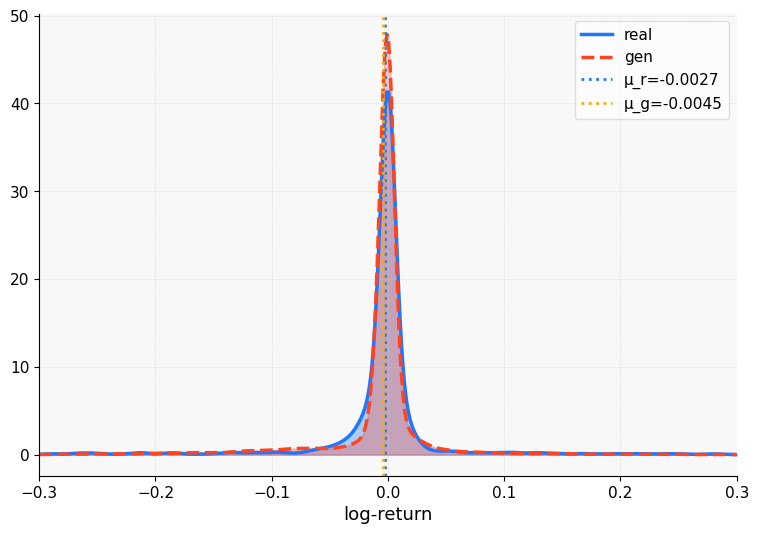

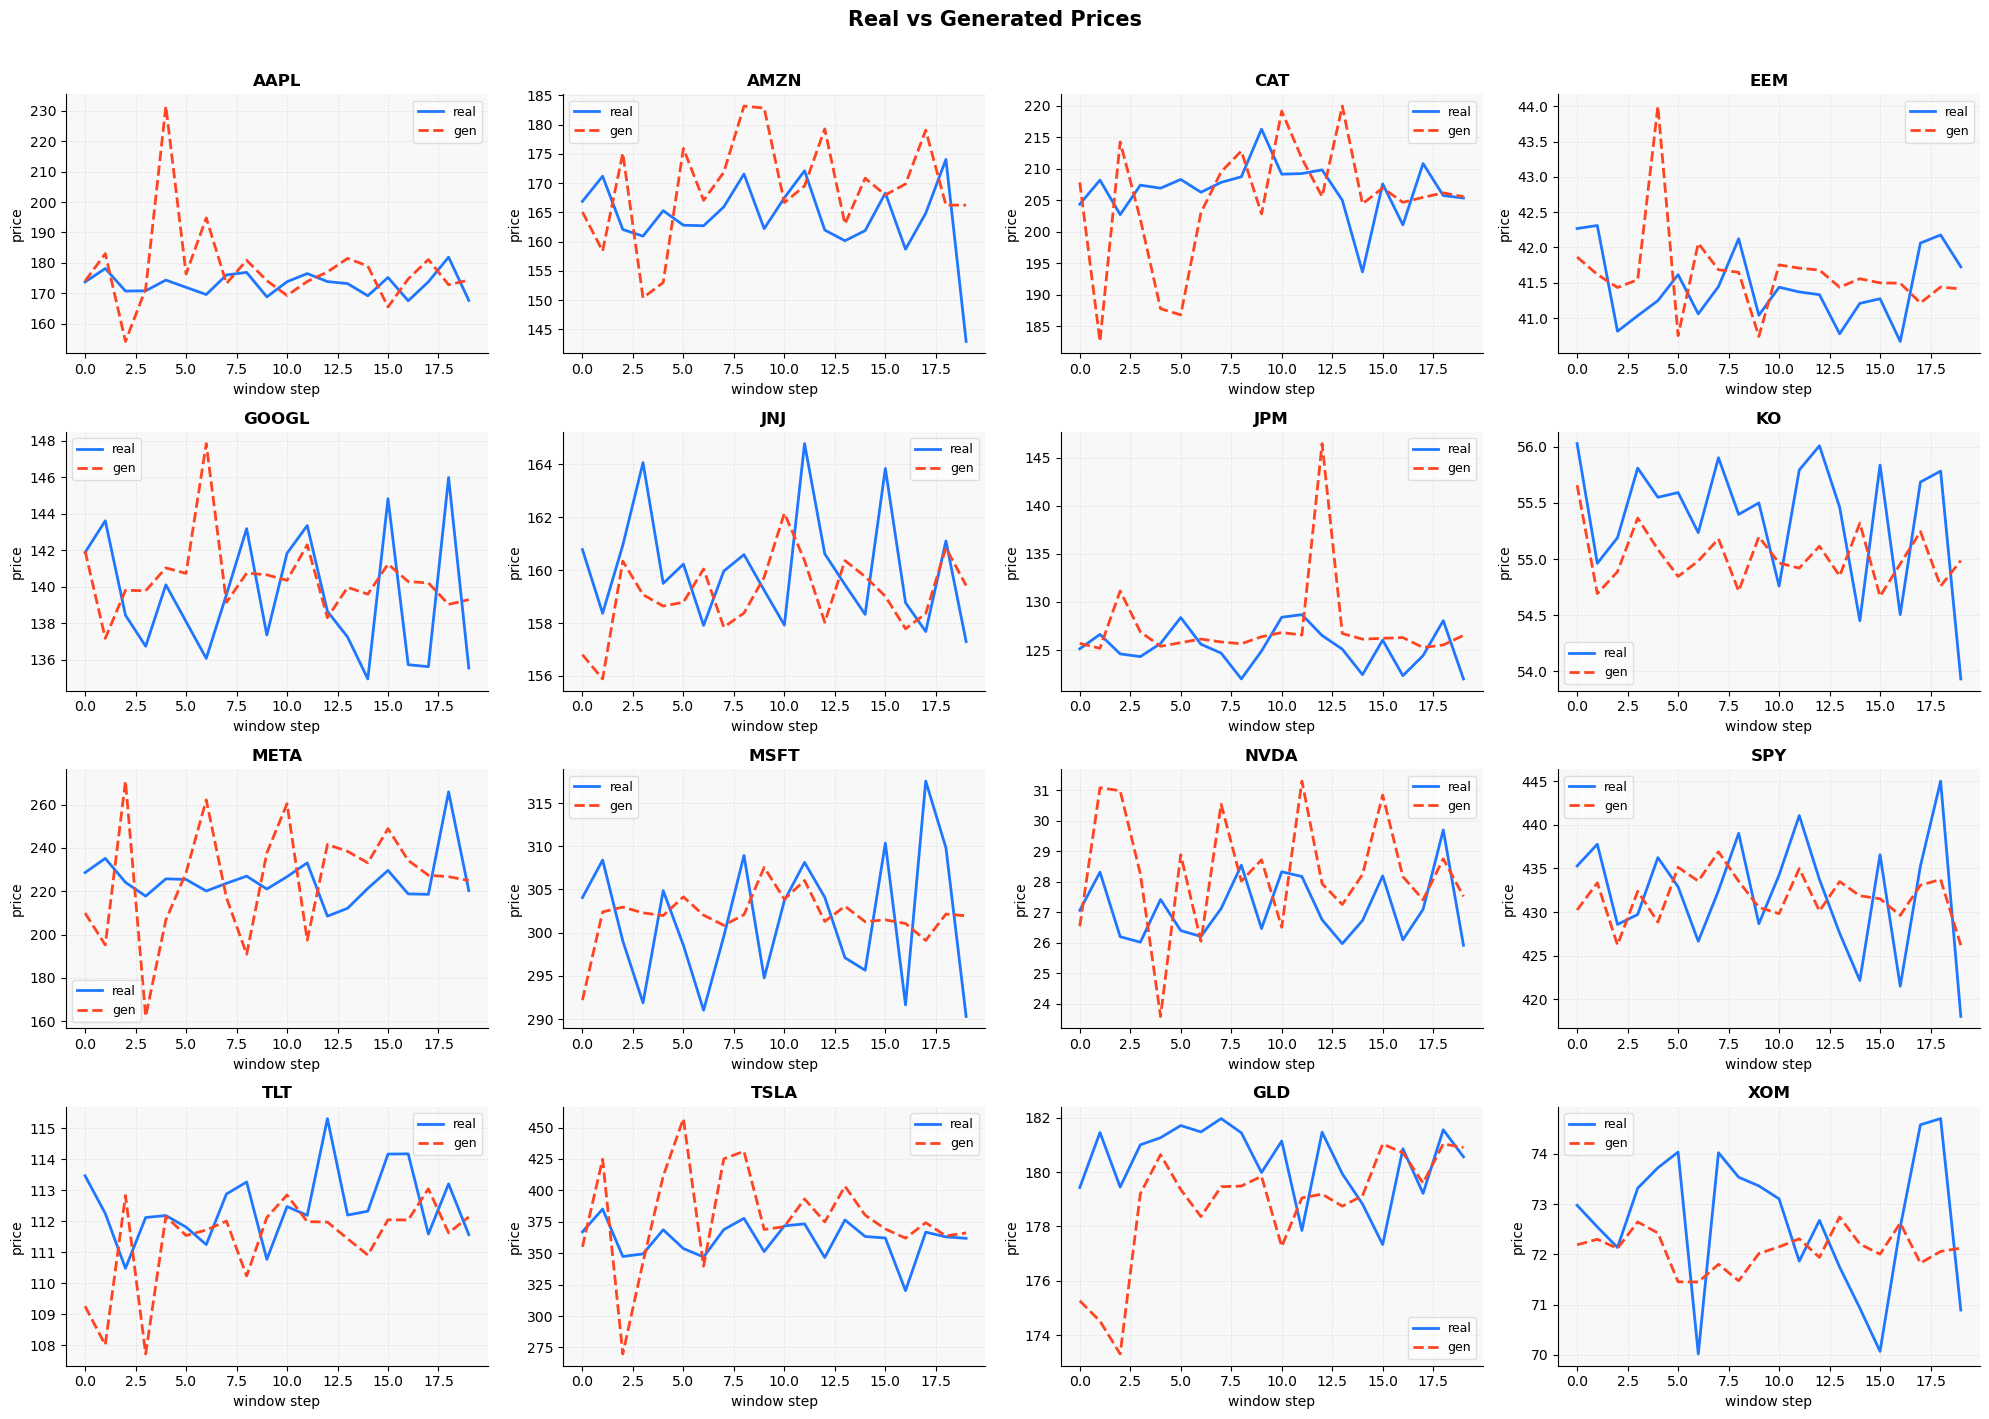

In [38]:
# df = compare_predictions(x_w, x_single, x_scaler, init_price_w)

x_w_real, prices_w_real = decode(x_w, x_scaler, init_price_w, 0)
x_w_gen, prices_w_gen = decode(x_single, x_scaler, init_price_w, 0)

print(f"{x_w_real.squeeze(0).shape}")
print(f"{x_w_gen.shape}")

# hello .squeeze(0)
plot_log_return_dist(x_w_real.squeeze(0), x_w_gen)
plot_prices_comparison(
    prices_w_real,
    prices_w_gen,
    stock_names=SYMBOLS,  # optional
    seq_idx=0,
)

In [39]:
@torch.no_grad()
def run_scenario(cond_base, inject_f_idxs, inject_val, sample_fn, n_sims):
    """cond_base : [1, A, W, F]"""
    cond_mod = cond_base.clone()
    for f in inject_f_idxs:
        cond_mod[:, :, :, f] = inject_val   # [1, A, W] ← 4 dims
    return mc_simulate(sample_fn, cond_mod, n_sims)

def debug_inject_scenario(
    sample_fn,
    x_w         : torch.Tensor,
    cond_w      : torch.Tensor,
    init_price_w: torch.Tensor,
    x_scaler,
    scenarios   : list[tuple[str, list[int]]],
    inject_vals : list[float],
    loader,                              # ← เพิ่ม loader เพื่อดึง cond window ถัดไป
    n_sims      : int = 50,
    ncols       : int = 3,
    cond_shift_windows: list[int] = [],  # ← เช่น [1, 2, 5] = เอา cond window +1, +2, +5
):
    cond_base = cond_w.float()
    init_p    = init_price_w.squeeze(0)

    # ── โหลด cond windows ล่วงหน้าถ้าต้องการ shift ──────────────
    shifted_conds = {}
    if cond_shift_windows:
        max_shift = max(cond_shift_windows)
        cond_buffer = [cond_base]  # index 0 = window ปัจจุบัน
        loader_iter = iter(loader)
        next(loader_iter)          # skip window แรก (ที่เราใช้อยู่แล้ว)
        for _ in range(max_shift):
            try:
                _, cond_next, *_ = next(loader_iter)
                cond_buffer.append(cond_next.float())
            except StopIteration:
                break
        for s in cond_shift_windows:
            if s < len(cond_buffer):
                shifted_conds[s] = cond_buffer[s]
            else:
                print(f"  ⚠️ shift={s} เกิน loader ที่มี skip ไป")

    # ── 1. run simulations ──────────────────────────────────────
    results = {}
    x_baseline          = mc_simulate(sample_fn, cond_base, n_sims)
    results["baseline"] = decode_simulation(x_baseline, x_scaler, init_p)

    for label, f_idxs in scenarios:
        for val in inject_vals:
            key          = f"{label}  val={val:+.0f}"
            x_gen        = run_scenario(cond_base, f_idxs, val, sample_fn, n_sims)
            results[key] = decode_simulation(x_gen, x_scaler, init_p)
            print(f"  ✓ {key}")

    for s, cond_s in shifted_conds.items():
        key          = f"cond_shift  w+{s}"
        x_gen        = mc_simulate(sample_fn, cond_s, n_sims)
        results[key] = decode_simulation(x_gen, x_scaler, init_p)
        print(f"  ✓ {key}")

    # ── 2. stats table ──────────────────────────────────────────
    def _lr(decoded): return decoded["log_returns"][..., 0, 0, 0].flatten()

    base_mean = _lr(results["baseline"]).mean()
    base_std  = _lr(results["baseline"]).std()
    real_flat = _lr(decode_simulation(x_w.float(), x_scaler, init_p))

    print(f"\n{'scenario':<40} {'mean':>9} {'std':>9} {'p05':>9} {'p95':>9}  Δmean  Δstd")
    print("─" * 90)
    for key, decoded in results.items():
        lr       = _lr(decoded)
        m, s     = lr.mean(), lr.std()
        p05, p95 = np.percentile(lr, 5), np.percentile(lr, 95)
        dm, ds   = m - base_mean, s - base_std
        flag     = "  ⚠️" if abs(dm) > 0.005 or abs(ds) > 0.005 else ""
        print(f"{key:<40} {m:>+9.5f} {s:>9.5f} {p05:>+9.5f} {p95:>+9.5f}  {dm:+.4f}  {ds:+.4f}{flag}")

    # ── 3. plot ─────────────────────────────────────────────────
    n     = len(results)
    nrows = math.ceil(n / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 9, nrows * 6))
    axes = axes.flatten()

    for i, (key, decoded) in enumerate(results.items()):
        gen_flat          = _lr(decoded)
        gen_mean, gen_std = gen_flat.mean(), gen_flat.std()
        xs    = np.linspace(gen_mean - 3*gen_std, gen_mean + 3*gen_std, 500)
        kde_r = gaussian_kde(real_flat)(xs)
        kde_g = gaussian_kde(gen_flat)(xs)
        ax = axes[i]
        ax.fill_between(xs, kde_r, alpha=0.35, color="#1f77ff")
        ax.plot(xs, kde_r, color="#1f77ff", lw=2.5, label=f"real  μ={real_flat.mean():.4f}")
        ax.fill_between(xs, kde_g, alpha=0.30, color="#ff4422")
        ax.plot(xs, kde_g, color="#ff4422", lw=2.5, linestyle="--", label=f"gen  μ={gen_flat.mean():.4f}")
        ax.axvline(real_flat.mean(), color="#1f77ff", lw=2.0, linestyle=":")
        ax.axvline(gen_flat.mean(),  color="#ffaa00", lw=2.0, linestyle=":")
        ax.set_title(key, fontsize=14, fontweight="bold")
        ax.set_xlabel("log-return", fontsize=13)
        ax.legend(fontsize=11, framealpha=0.6)
        ax.set_facecolor("#f8f8f8")
        ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.5, color="#cccccc")
        ax.spines[["top", "right"]].set_visible(False)

    for j in range(n, len(axes)):
        axes[j].set_visible(False)

    fig.suptitle("Log Return Distribution: Real vs Scenario", fontsize=16, fontweight="bold", y=1.01)
    plt.tight_layout()
    plt.show()

    return results

  ✓ f=2 BB_mid  val=-5000


/tmp/ipykernel_76005/3466426400.py:27: RuntimeWarning: overflow encountered in exp
  close_prices = init[..., np.newaxis] * np.exp(cum)


  ✓ f=2 BB_mid  val=+10000


/tmp/ipykernel_76005/3466426400.py:27: RuntimeWarning: overflow encountered in exp
  close_prices = init[..., np.newaxis] * np.exp(cum)


  ✓ f=5 MACD_hist  val=-5000
  ✓ f=5 MACD_hist  val=+10000


...

  ✓ f=1,2,3 all_BBANDS  val=+10000


/tmp/ipykernel_76005/3466426400.py:27: RuntimeWarning: overflow encountered in exp
  close_prices = init[..., np.newaxis] * np.exp(cum)


  ✓ f=4,5,6 all_MACD  val=-5000
  ✓ f=4,5,6 all_MACD  val=+10000
  ✓ f=0..8 ALL  val=-5000


/tmp/ipykernel_76005/3466426400.py:27: RuntimeWarning: overflow encountered in exp
  close_prices = init[..., np.newaxis] * np.exp(cum)


  ✓ f=0..8 ALL  val=+10000
  ✓ cond_shift  w+1
  ✓ cond_shift  w+2
  ✓ cond_shift  w+3
  ✓ cond_shift  w+5

scenario                                      mean       std       p05       p95  Δmean  Δstd
──────────────────────────────────────────────────────────────────────────────────────────
baseline                                  -0.02509   0.04279  -0.09704  +0.02408  +0.0000  +0.0000
f=2 BB_mid  val=-5000                    -22.72399   0.30785 -23.22150 -22.22291  -22.6989  +0.2651  ⚠️
f=2 BB_mid  val=+10000                   +47.17444   0.32127 +46.56871 +47.57708  +47.1995  +0.2785  ⚠️
f=5 MACD_hist  val=-5000                 +38.16785   0.28895 +37.77745 +38.62986  +38.1929  +0.2462  ⚠️
f=5 MACD_hist  val=+10000                -75.26070   0.22604 -75.60574 -74.87917  -75.2356  +0.1833  ⚠️
f=8 RSI  val=-5000                       +22.47475   0.22935 +22.05184 +22.79063  +22.4998  +0.1866  ⚠️
f=8 RSI  val=+10000                      -44.91451   0.32071 -45.44103 -44.41337  -44.88

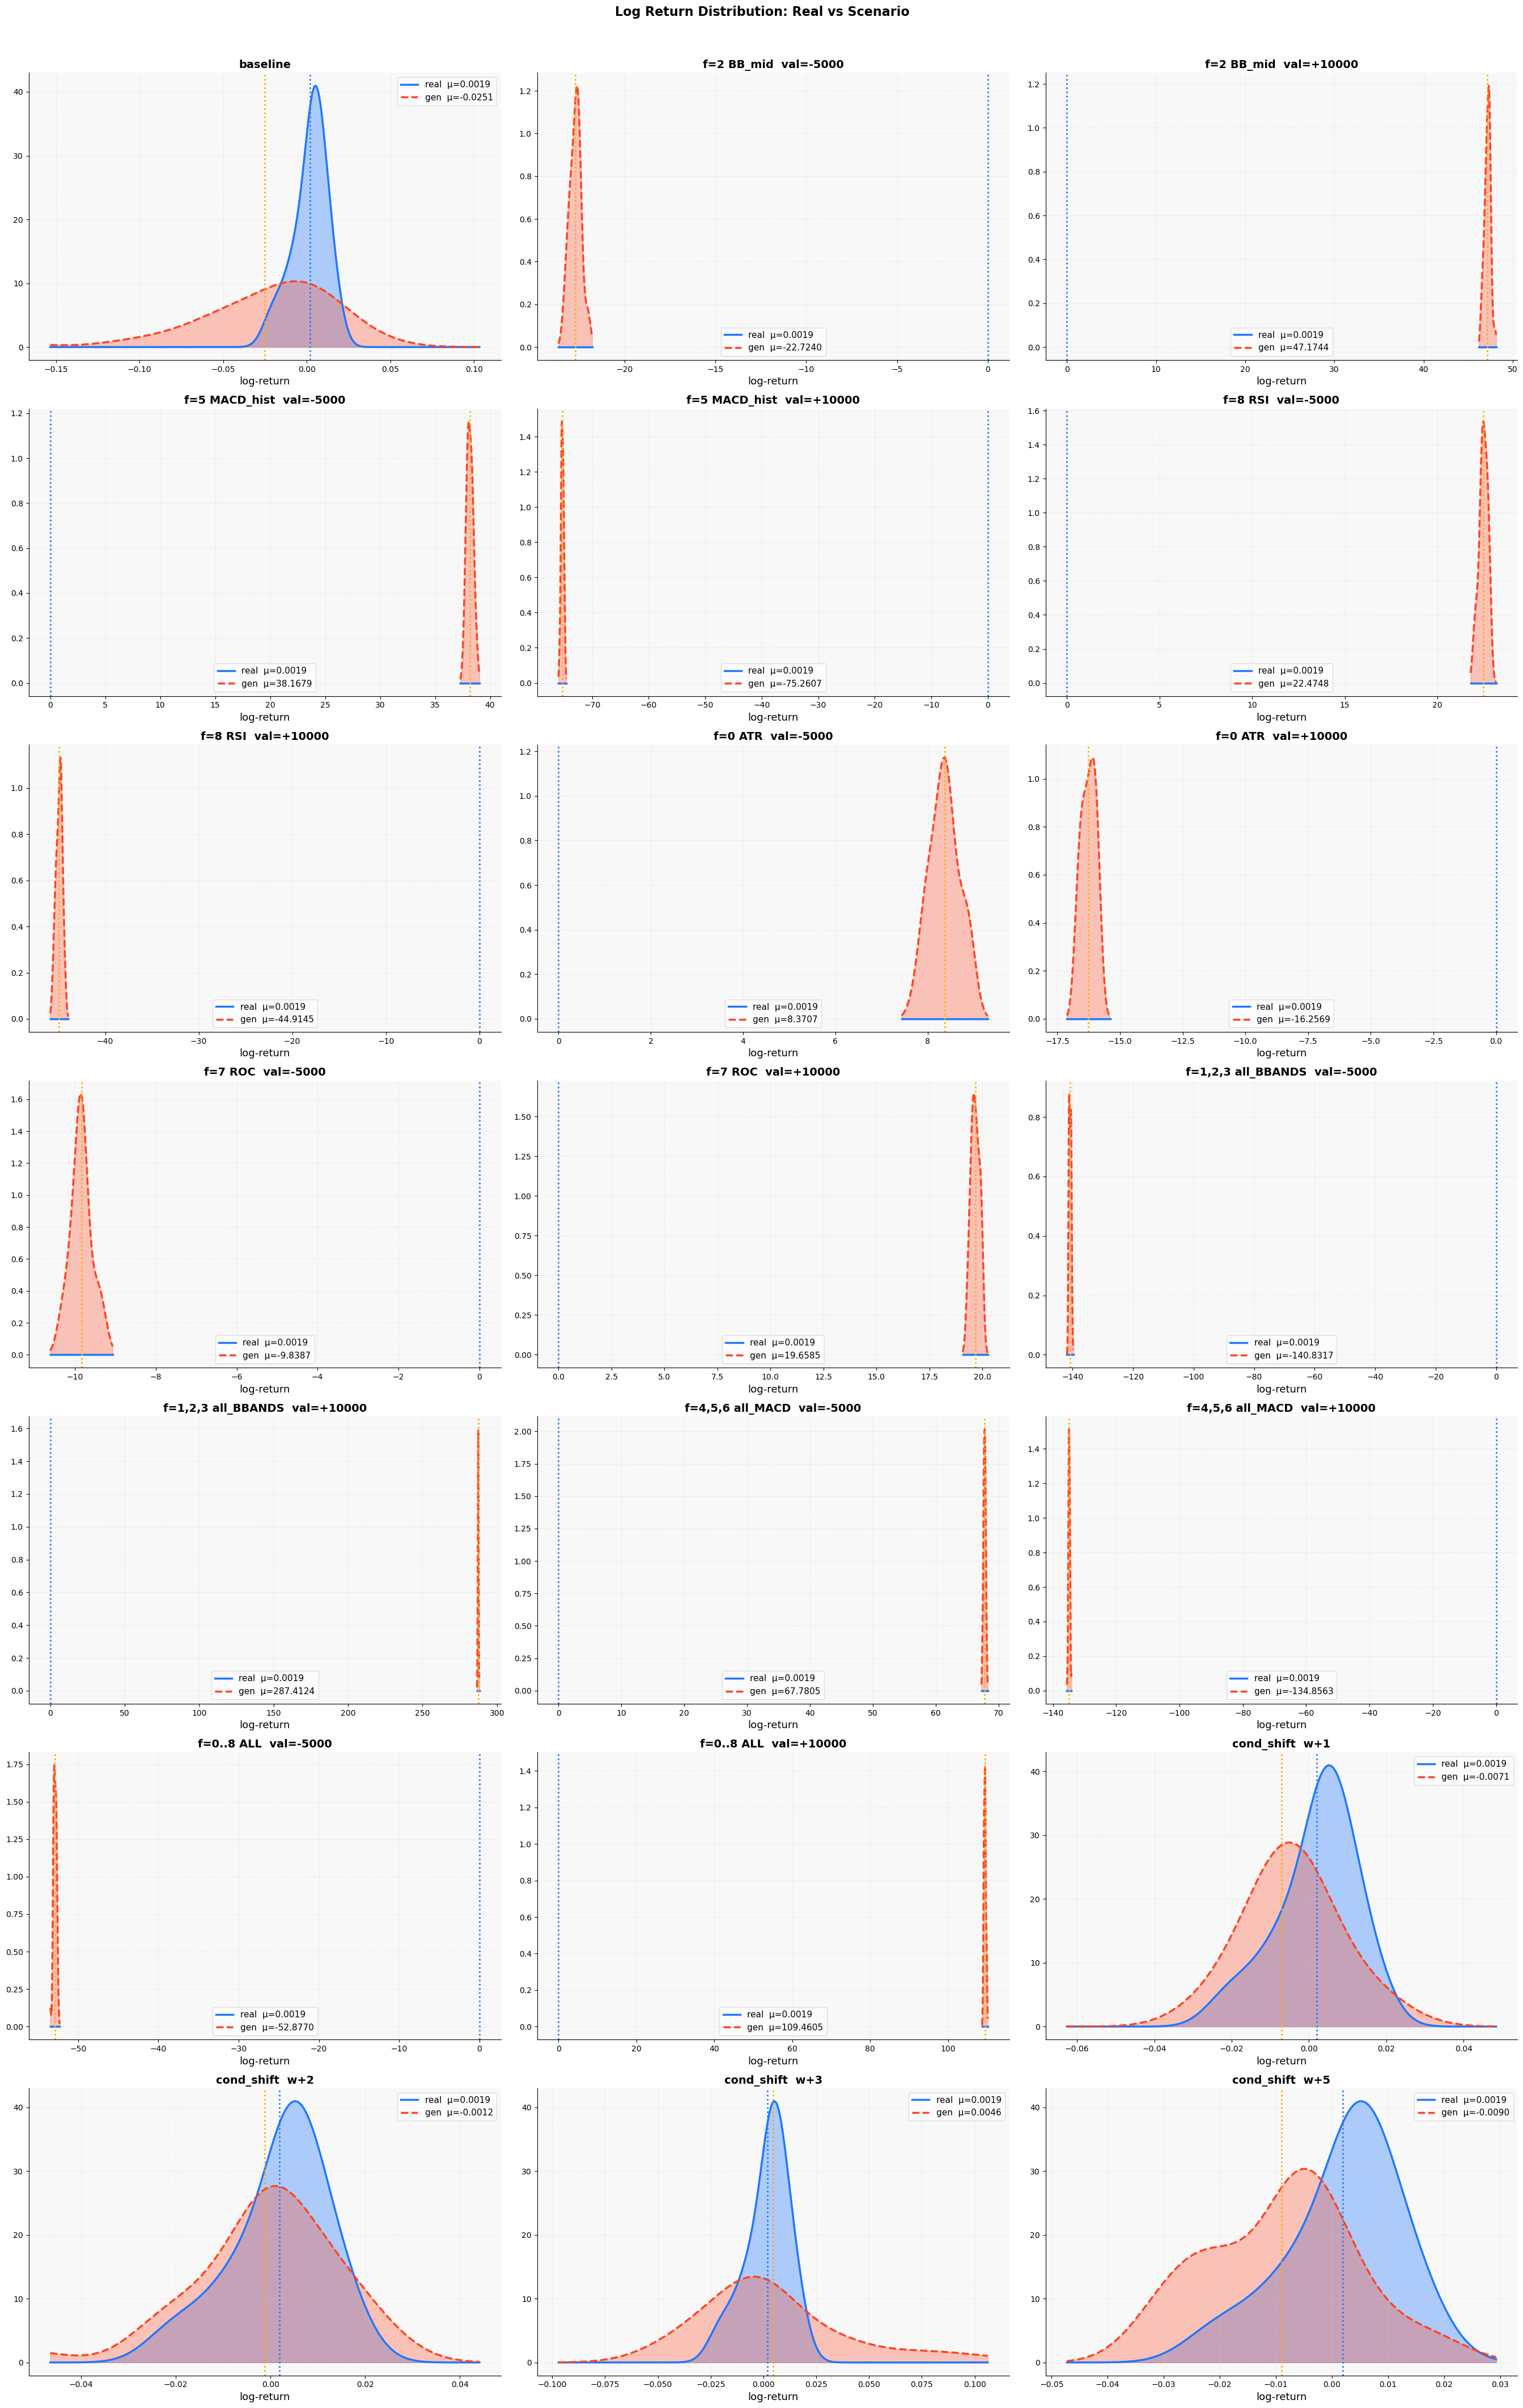

In [40]:
if not skip_injection:
    results = debug_inject_scenario(
        sample_fn          = ddpm_sample_fn,
        x_w                = x_w,
        cond_w             = cond_w,
        init_price_w       = init_price_w,
        x_scaler           = x_scaler,
        scenarios          = injection.scenarios,
        inject_vals        = injection.values,
        loader             = loaders["test"],
        n_sims             = inf_cfg.num_simulations,
        cond_shift_windows = injection.cond_window_shift,
    )

# 4. Simulate

In [41]:
sim_dir = inf_cfg.simulation_dir
sim_dir.mkdir(parents=True, exist_ok=True)
print(f"  sim_dir: {sim_dir}")

results = []

for batch_idx, batch in enumerate(tqdm(loaders["test"], desc="simulate_all_test")):
    x_w, cond_w, init_price_w, ohlcv_w, dates_w, init_date_w = batch

    # squeeze batch dim (batch_size=1)
    x_ref        = x_w.squeeze(0)           # [A, W, D, C]
    cond         = cond_w.squeeze(0)         # [A, W, F]
    init_price   = init_price_w.squeeze(0)   # [A]
    init_date    = init_date_w.squeeze(0)
    dates        = dates_w.squeeze(0)        # [W]
    ohlcv        = ohlcv_w.squeeze(0)        # [A, W, D, C]

    sample_fn = make_ddpm_sample_fn(
            model     = model,
            data_cfg  = data_cfg,
            cond_dims = COND_DIMS,
            x_dims    = X_DIMS,
            x_ref     = x_w,       # [1, A, W, D, C]
            device    = inf_cfg.device,
    )

    x_gen = mc_simulate(sample_fn, cond_w, inf_cfg.num_simulations)

    log_returns, prices = decode(
            x        = x_gen,
            x_scaler = x_scaler,
            init_price = init_price_w,
            idx_channel = 0,
        )

    results.append({
            "batch_idx"  : batch_idx,
            "x_gen"      : x_gen.cpu(),
            "x_real"     : x_ref.cpu(),
            "cond"       : cond.cpu(),
            "init_price" : init_price.cpu(),
            "init_date"  : init_date.cpu(),
            "dates"      : dates.cpu(),
            "ohlcv"      : ohlcv.cpu(),
            "log_returns": log_returns,
            "prices"     : prices,
    })

    batch_path = sim_dir / f"batch_{batch_idx:03d}.npz"
    np.savez_compressed(
        batch_path,
        x_gen        = x_gen.cpu().numpy(),
        x_real       = x_ref.cpu().numpy(),
        cond         = cond.cpu().numpy(),
        init_price   = init_price.cpu().numpy(),
        init_date    = init_date.cpu().numpy().astype("int64"),
        dates        = dates.cpu().numpy().astype("int64"),
        ohlcv        = ohlcv.cpu().numpy(),
        log_returns  = log_returns,
        prices       = prices,
    )

print(f"\n✓ simulate_all_test done  windows={len(results)}")


  sim_dir: /home/narodom.y@FUSION.LAB/research/02_experiments/v1_trial04_ddpm_warmup-cosine_w20_d20_seqWA_featDC_robust_standard/simulations/beta_n100_simulations_independent_windows_rand72


simulate_all_test:   0%|                                                                        | 0/46 [00:00<?, ?it/s]/tmp/ipykernel_76005/3630632120.py:33: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  init_price = np.array(init_price).reshape(1, 16, 1, 1)
simulate_all_test:   2%|█▍                                                              | 1/46 [00:06<04:59,  6.65s/it]/tmp/ipykernel_76005/3630632120.py:33: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  init_price = np


✓ simulate_all_test done  windows=46


In [42]:
import json
from datetime import datetime, timezone

meta_out = {
    "created_at"      : datetime.now(timezone.utc).isoformat(),
    "experiment_name" : inf_cfg.experiment_name,
    "simulation_name" : inf_cfg.simulation_name,
    "checkpoint_file" : inf_cfg.checkpoint_file,
    "num_simulations" : inf_cfg.num_simulations,
    "random_seed"     : inf_cfg.random_seed,
    "n_windows"       : len(results),
    "symbols"         : SYMBOLS,
    "sim_dir"         : str(sim_dir),
}

with open(sim_dir / "meta.json", "w") as f:
    json.dump(meta_out, f, indent=2)

print(f"  ✓ meta.json saved → {sim_dir / 'meta.json'}")
print(f"  ✓ batches saved   → {sim_dir}/batch_NNNNN.npz  ({len(results)} files)")

  ✓ meta.json saved → /home/narodom.y@FUSION.LAB/research/02_experiments/v1_trial04_ddpm_warmup-cosine_w20_d20_seqWA_featDC_robust_standard/simulations/beta_n100_simulations_independent_windows_rand72/meta.json
  ✓ batches saved   → /home/narodom.y@FUSION.LAB/research/02_experiments/v1_trial04_ddpm_warmup-cosine_w20_d20_seqWA_featDC_robust_standard/simulations/beta_n100_simulations_independent_windows_rand72/batch_NNNNN.npz  (46 files)


In [43]:
from torch.utils.data import Dataset, DataLoader

class SimulationDataset(Dataset):
    def __init__(self, sim_dir: Path):
        self.sim_dir = sim_dir
        with open(sim_dir / "meta.json") as f:
            self.meta = json.load(f)
        self.n = self.meta["n_windows"]

    def __len__(self):
        return self.n

    def __getitem__(self, idx):
        raw = np.load(self.sim_dir / f"batch_{idx:05d}.npz")
        return {k: raw[k] for k in raw.files}

# 5. Plot & Save Distribution

  plot_dir: /home/narodom.y@FUSION.LAB/research/02_experiments/v1_trial04_ddpm_warmup-cosine_w20_d20_seqWA_featDC_robust_standard/plots/beta_n100_simulations_independent_windows_rand72
  real samples : 294,400
  gen  samples : 2,355,200
  real μ=0.00026  σ=0.01424
  gen  μ=-0.00110  σ=0.06881


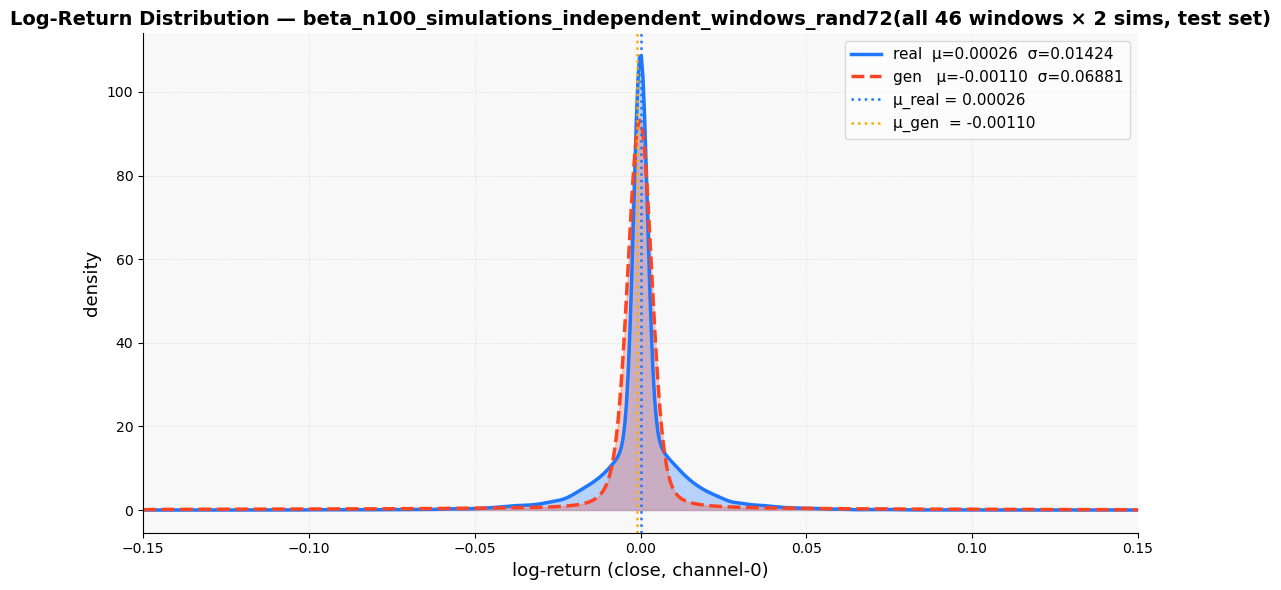

  ✓ saved → /home/narodom.y@FUSION.LAB/research/02_experiments/v1_trial04_ddpm_warmup-cosine_w20_d20_seqWA_featDC_robust_standard/plots/beta_n100_simulations_independent_windows_rand72/dist_aggregate.png


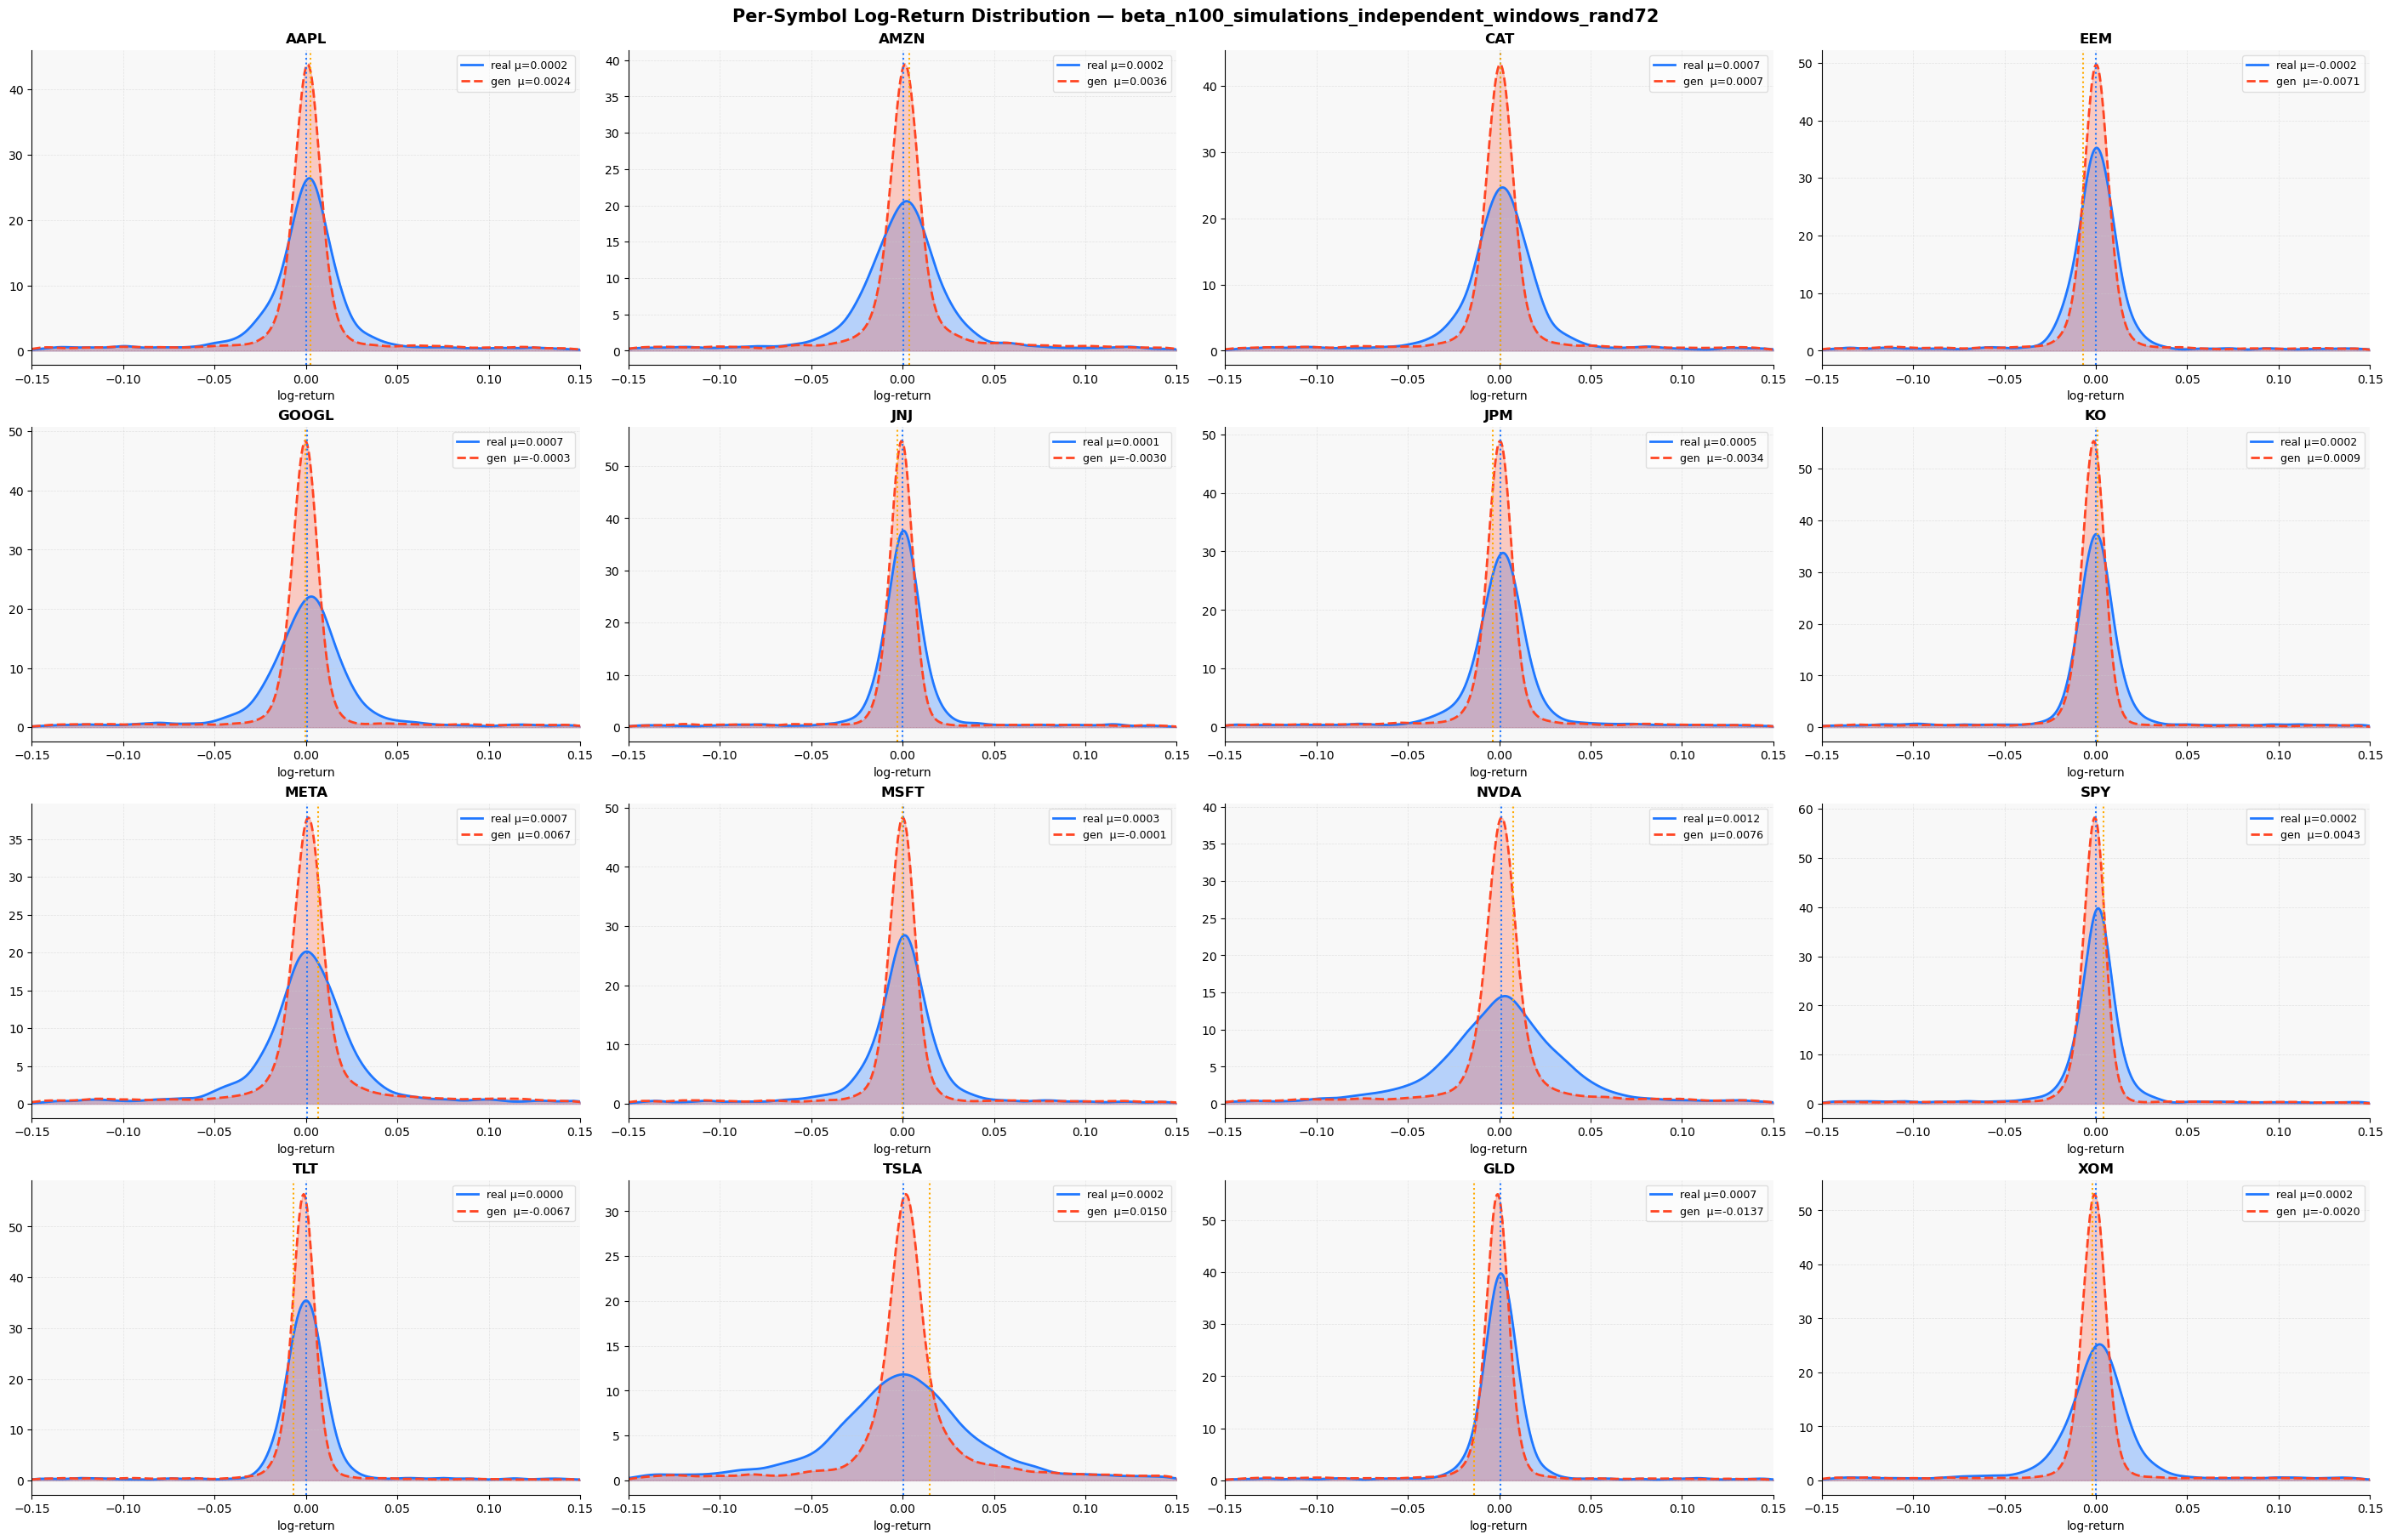

  ✓ saved → /home/narodom.y@FUSION.LAB/research/02_experiments/v1_trial04_ddpm_warmup-cosine_w20_d20_seqWA_featDC_robust_standard/plots/beta_n100_simulations_independent_windows_rand72/dist_per_symbol.png
AAPL          +0.00018   0.15082  +0.00237   0.12770  +0.00219  -0.02312  ⚠️
AMZN          +0.00020   0.15687  +0.00358   0.12909  +0.00338  -0.02777  ⚠️
CAT           +0.00066   0.18620  +0.00067   0.12862  +0.00001  -0.05758  ⚠️
EEM           -0.00017   0.17335  -0.00707   0.12911  -0.00690  -0.04424  ⚠️
GOOGL         +0.00069   0.16700  -0.00033   0.12395  -0.00102  -0.04305  ⚠️
JNJ           +0.00013   0.16828  -0.00303   0.13578  -0.00315  -0.03250  ⚠️
JPM           +0.00052   0.15800  -0.00337   0.12480  -0.00390  -0.03320  ⚠️
KO            +0.00017   0.16438  +0.00085   0.16404  +0.00068  -0.00034
META          +0.00069   0.17598  +0.00670   0.14036  +0.00601  -0.03562  ⚠️
MSFT          +0.00030   0.15809  -0.00006   0.13066  -0.00037  -0.02743  ⚠️
NVDA          +0.00124   0.13

In [44]:
# ── 5.1  รวม log-returns จากทุก batch ──────────────────────────────
plot_dir = inf_cfg.experiment_dir / "plots" / inf_cfg.simulation_name
plot_dir.mkdir(parents=True, exist_ok=True)
print(f"  plot_dir: {plot_dir}")

all_real_lr = []
all_gen_lr  = []

for r in results:
    # x_real: [A, W, D, C]  →  log-returns ผ่าน inverse_x
    x_real_np = r["x_real"].numpy()
    orig_shape = x_real_np.shape
    lr_real = inverse_x(x_real_np.reshape(-1, orig_shape[-1]), x_scaler).reshape(orig_shape)
    all_real_lr.append(lr_real[..., 0].flatten())   # channel 0 (close)

    # log_returns stored in results: shape depends on decode() output
    all_gen_lr.append(np.array(r["log_returns"]).flatten())

real_flat = np.concatenate(all_real_lr)
gen_flat  = np.concatenate(all_gen_lr)

print(f"  real samples : {real_flat.shape[0]:,}")
print(f"  gen  samples : {gen_flat.shape[0]:,}")
print(f"  real μ={real_flat.mean():.5f}  σ={real_flat.std():.5f}")
print(f"  gen  μ={gen_flat.mean():.5f}  σ={gen_flat.std():.5f}")

# ── 5.2  KDE distribution plot (aggregate) ─────────────────────────
clip  = 0.15
xs    = np.linspace(-clip, clip, 600)

# กรองค่า outlier ก่อน KDE
r_clip = real_flat[np.abs(real_flat) <= clip]
g_clip = gen_flat[np.abs(gen_flat)   <= clip]

kde_r = gaussian_kde(r_clip, bw_method=0.15)(xs)
kde_g = gaussian_kde(g_clip, bw_method=0.15)(xs)

fig, ax = plt.subplots(figsize=(11, 6))

ax.fill_between(xs, kde_r, alpha=0.30, color="#1f77ff")
ax.plot(xs, kde_r, color="#1f77ff", lw=2.5,
        label=f"real  μ={real_flat.mean():.5f}  σ={real_flat.std():.5f}")

ax.fill_between(xs, kde_g, alpha=0.25, color="#ff4422")
ax.plot(xs, kde_g, color="#ff4422", lw=2.5, linestyle="--",
        label=f"gen   μ={gen_flat.mean():.5f}  σ={gen_flat.std():.5f}")

ax.axvline(real_flat.mean(), color="#1f77ff", lw=1.8, linestyle=":",
           label=f"μ_real = {real_flat.mean():.5f}")
ax.axvline(gen_flat.mean(),  color="#ffaa00", lw=1.8, linestyle=":",
           label=f"μ_gen  = {gen_flat.mean():.5f}")

ax.set_xlim(-clip, clip)
ax.set_xlabel("log-return (close, channel-0)", fontsize=13)
ax.set_ylabel("density", fontsize=13)
ax.set_title(
    f"Log-Return Distribution — {inf_cfg.simulation_name}"
    f"(all {len(results)} windows × {inf_cfg.num_simulations} sims, test set)",
    fontsize=14, fontweight="bold",
)
ax.legend(fontsize=11, framealpha=0.7, edgecolor="#cccccc")
ax.set_facecolor("#f8f8f8")
ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.5, color="#cccccc")
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
agg_path = plot_dir / "dist_aggregate.png"
fig.savefig(agg_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"  ✓ saved → {agg_path}")

# ── 5.3  Per-symbol distribution (subplot grid) ────────────────────
n_assets = results[0]["x_real"].shape[0]   # A dimension
ncols    = 4
nrows    = math.ceil(n_assets / ncols)

fig2, axes2 = plt.subplots(nrows, ncols,
                            figsize=(ncols * 7, nrows * 4.5),
                            constrained_layout=True)
axes2 = axes2.flatten()

for a in range(n_assets):
    sym = SYMBOLS[a] if a < len(SYMBOLS) else f"Asset {a}"
    ax  = axes2[a]

    # รวม real log-returns สำหรับ asset a
    r_a = np.concatenate([
        inverse_x(
            r["x_real"].numpy().reshape(-1, r["x_real"].shape[-1]),
            x_scaler
        ).reshape(r["x_real"].shape)[a, :, 0].flatten()      # [W, D] → channel-0
        for r in results
    ])
    # รวม gen log-returns สำหรับ asset a  (log_returns shape: [N, A, W, (D,) C])
    g_a = np.concatenate([
        np.array(r["log_returns"])[:, a, :, 0].flatten()     # [N, W] channel-0
        for r in results
    ])

    r_a_clip = r_a[np.abs(r_a) <= clip]
    g_a_clip = g_a[np.abs(g_a) <= clip]

    if len(r_a_clip) < 5 or len(g_a_clip) < 5:
        ax.set_title(f"{sym} (insufficient data)", fontsize=11)
        continue

    kde_ra = gaussian_kde(r_a_clip, bw_method=0.15)(xs)
    kde_ga = gaussian_kde(g_a_clip, bw_method=0.15)(xs)

    ax.fill_between(xs, kde_ra, alpha=0.30, color="#1f77ff")
    ax.plot(xs, kde_ra, color="#1f77ff", lw=2.0,
            label=f"real μ={r_a.mean():.4f}")
    ax.fill_between(xs, kde_ga, alpha=0.25, color="#ff4422")
    ax.plot(xs, kde_ga, color="#ff4422", lw=2.0, linestyle="--",
            label=f"gen  μ={g_a.mean():.4f}")
    ax.axvline(r_a.mean(), color="#1f77ff", lw=1.5, linestyle=":")
    ax.axvline(g_a.mean(), color="#ffaa00", lw=1.5, linestyle=":")

    ax.set_xlim(-clip, clip)
    ax.set_title(sym, fontsize=12, fontweight="bold")
    ax.set_xlabel("log-return", fontsize=10)
    ax.legend(fontsize=9, framealpha=0.6, edgecolor="#cccccc")
    ax.set_facecolor("#f8f8f8")
    ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.5, color="#cccccc")
    ax.spines[["top", "right"]].set_visible(False)

# ซ่อน subplot ที่เกิน
for j in range(n_assets, len(axes2)):
    axes2[j].set_visible(False)

fig2.suptitle(
    f"Per-Symbol Log-Return Distribution — {inf_cfg.simulation_name}",
    fontsize=15, fontweight="bold",
)
sym_path = plot_dir / "dist_per_symbol.png"
fig2.savefig(sym_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"  ✓ saved → {sym_path}")

# ── 5.4  Summary stats table ────────────────────────────────────────
# print(f"{'symbol':<12} {'real_μ':>9} {'real_σ':>9} {'gen_μ':>9} {'gen_σ':>9}  {'Δμ':>8}  {'Δσ':>8}")print("─" * 75)
for a in range(n_assets):
    sym = SYMBOLS[a] if a < len(SYMBOLS) else f"Asset {a}"
    r_a = np.concatenate([
        inverse_x(
            r["x_real"].numpy().reshape(-1, r["x_real"].shape[-1]),
            x_scaler
        ).reshape(r["x_real"].shape)[a, :, 0].flatten()
        for r in results
    ])
    g_a = np.concatenate([
        np.array(r["log_returns"])[:, a, :, 0].flatten()
        for r in results
    ])
    dm = g_a.mean() - r_a.mean()
    ds = g_a.std()  - r_a.std()
    flag = "  ⚠️" if abs(dm) > 0.005 or abs(ds) > 0.005 else ""
    print(f"{sym:<12} {r_a.mean():>+9.5f} {r_a.std():>9.5f} {g_a.mean():>+9.5f} {g_a.std():>9.5f}  {dm:>+8.5f}  {ds:>+8.5f}{flag}")

print(f"✓ All distribution plots saved → {plot_dir}")

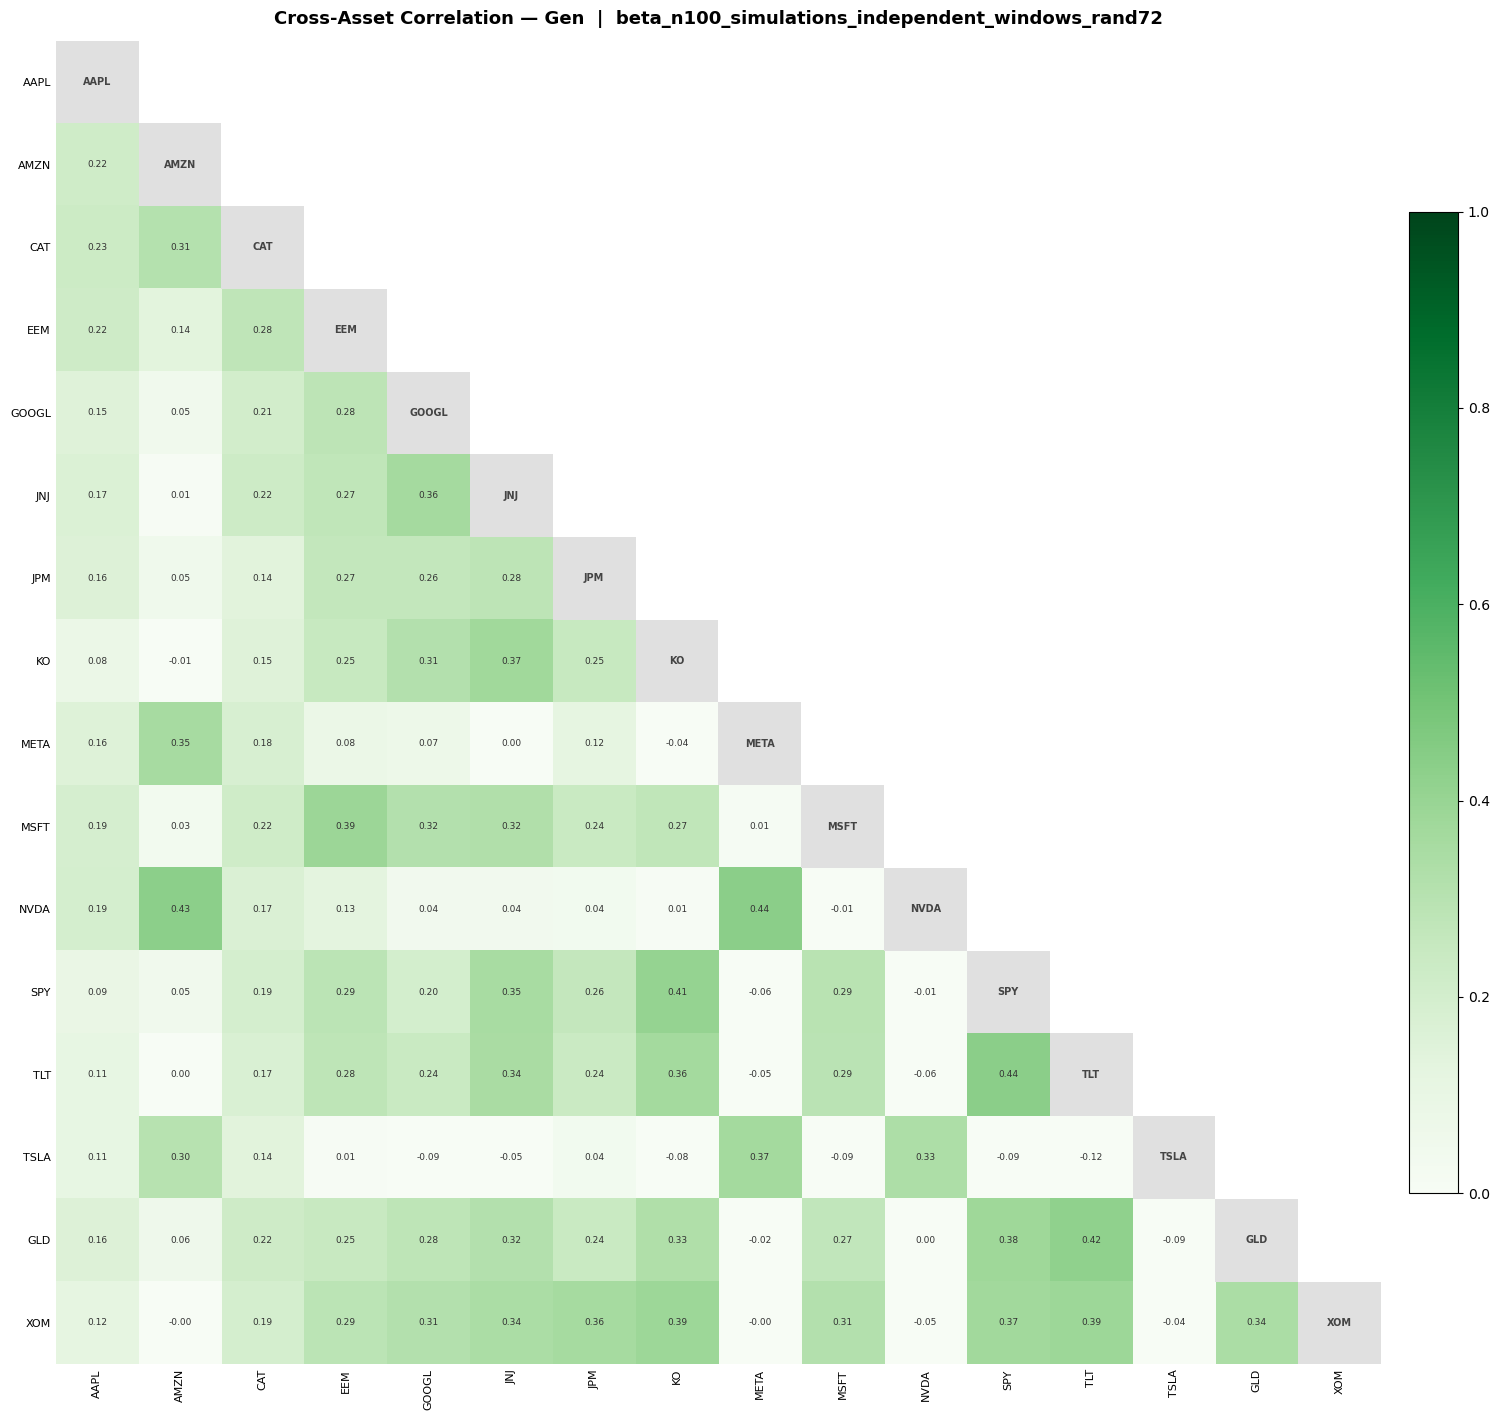

  ✓ saved → /home/narodom.y@FUSION.LAB/research/02_experiments/v1_trial04_ddpm_warmup-cosine_w20_d20_seqWA_featDC_robust_standard/plots/beta_n100_simulations_independent_windows_rand72/corr_gen.png


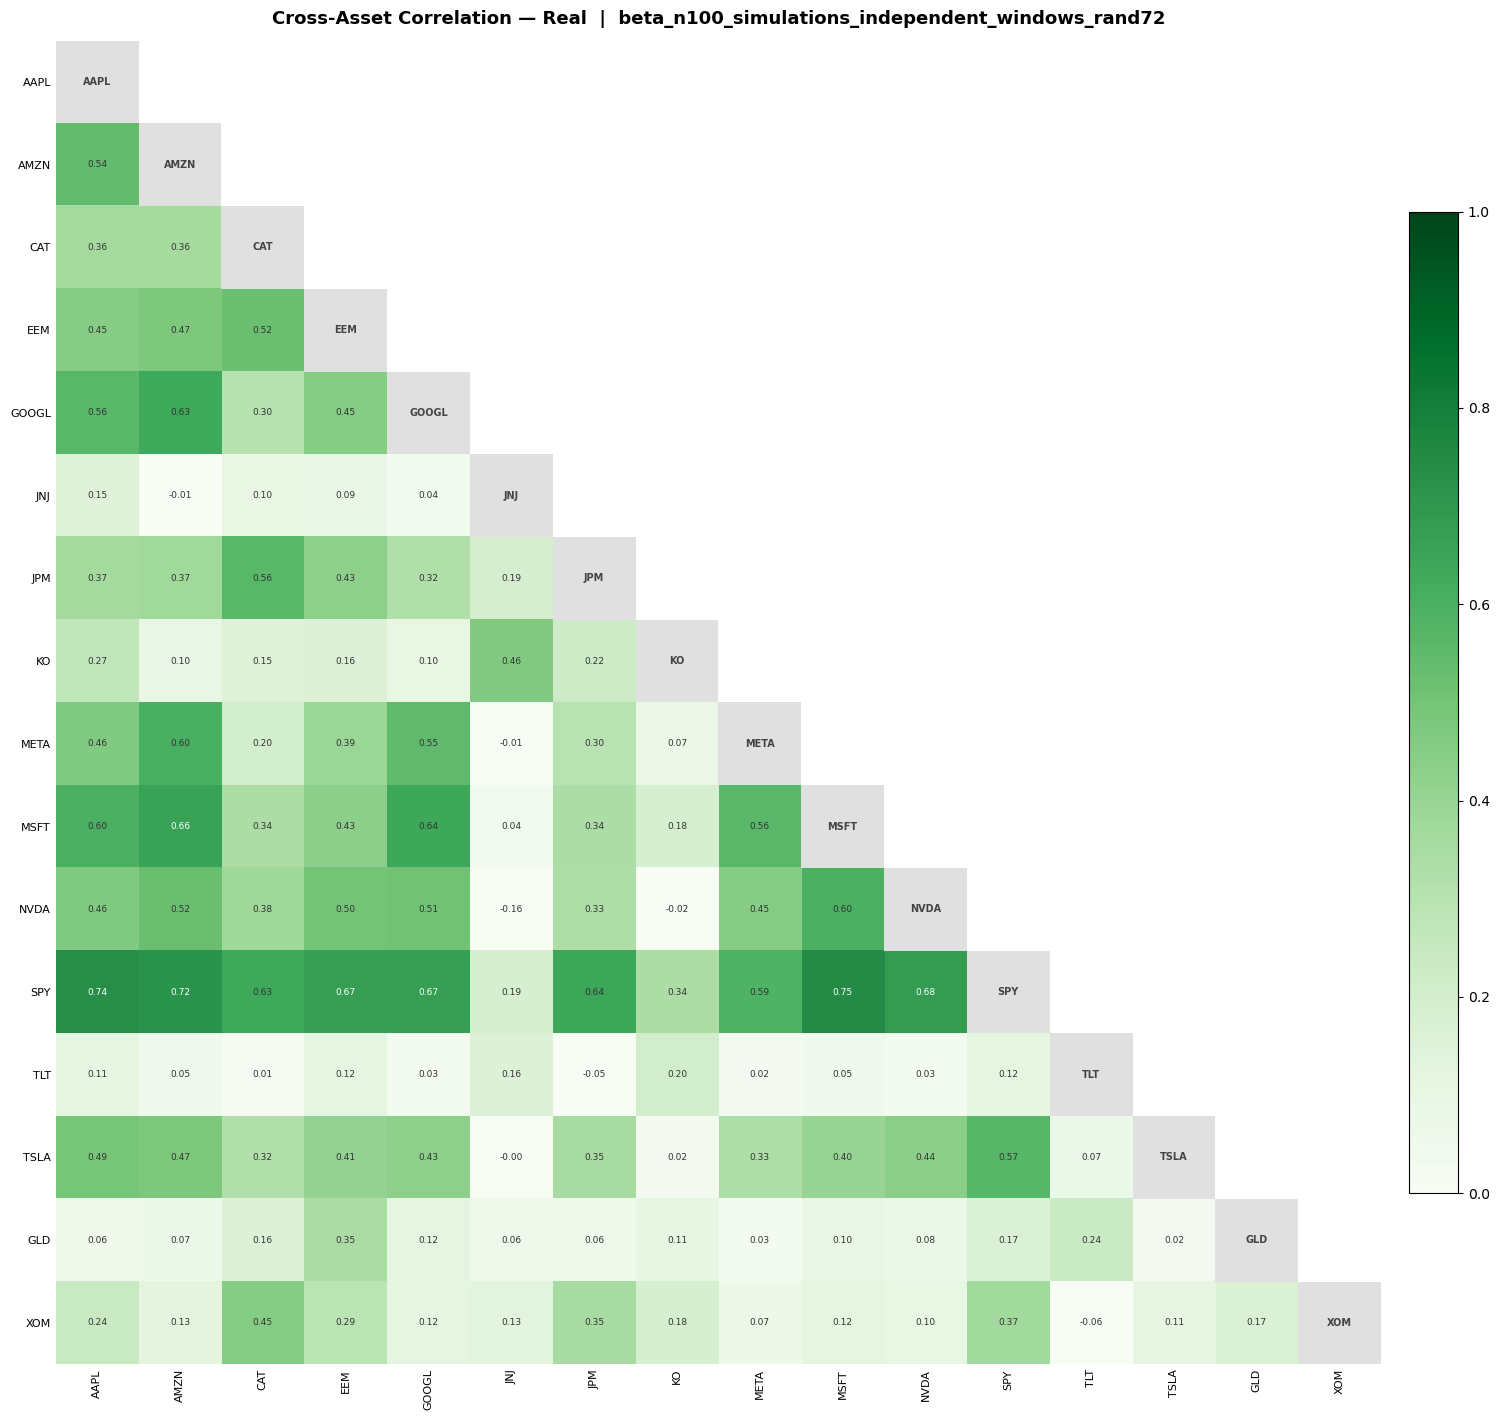

  ✓ saved → /home/narodom.y@FUSION.LAB/research/02_experiments/v1_trial04_ddpm_warmup-cosine_w20_d20_seqWA_featDC_robust_standard/plots/beta_n100_simulations_independent_windows_rand72/corr_real.png

Top correlation divergences (|gen−real|):
  pair                    real     gen     diff
  ────────────────────────────────────────────────
  SPY vs NVDA           +0.681  -0.008   -0.688
  SPY vs AMZN           +0.719  +0.049   -0.670
  TSLA vs SPY           +0.570  -0.087   -0.657
  SPY vs AAPL           +0.738  +0.091   -0.646
  SPY vs META           +0.586  -0.059   -0.645
  MSFT vs AMZN          +0.660  +0.033   -0.627
  NVDA vs MSFT          +0.600  -0.007   -0.607
  GOOGL vs AMZN         +0.634  +0.045   -0.589
  MSFT vs META          +0.559  +0.011   -0.548
  TSLA vs GOOGL         +0.428  -0.090   -0.518

✓ All plots saved → /home/narodom.y@FUSION.LAB/research/02_experiments/v1_trial04_ddpm_warmup-cosine_w20_d20_seqWA_featDC_robust_standard/plots/beta_n100_simulations_independent_

In [45]:
import matplotlib.patches as mpatches

# ── build per-asset log-return time-series ────────────────────────────
def _to_np(x):
    return x if isinstance(x, np.ndarray) else x.numpy()

_results = results if ('results' in dir() and len(results) > 0) else _load_results_from_disk(sim_dir)

real_ts, gen_ts = [], []
for a in range(n_assets):
    r_a = np.concatenate([
        inverse_x(
            _to_np(r["x_real"]).reshape(-1, _to_np(r["x_real"]).shape[-1]), x_scaler
        ).reshape(_to_np(r["x_real"]).shape)[a, ..., 0].flatten()
        for r in _results
    ])
    g_a = np.concatenate([
        np.array(r["log_returns"])[:, a, ..., 0].mean(axis=0).flatten()
        for r in _results
    ])
    real_ts.append(r_a)
    gen_ts.append(g_a)

min_len   = min(min(x.shape[0] for x in real_ts), min(x.shape[0] for x in gen_ts))
R         = np.stack([x[:min_len] for x in real_ts])
G         = np.stack([x[:min_len] for x in gen_ts])
corr_real = np.corrcoef(R)
corr_gen  = np.corrcoef(G)
corr_diff = corr_gen - corr_real

syms_short = [s[:6] for s in SYMBOLS] if SYMBOLS else [f"A{i}" for i in range(n_assets)]
A = n_assets

# ── helper: lower-triangle heatmap ───────────────────────────────────
def plot_lower_tri(corr_mat, title, save_path):
    fig, ax = plt.subplots(figsize=(max(9, A * 0.85 + 1.5), max(8, A * 0.8 + 1.5)))

    mask = np.tril(np.ones((A, A), dtype=bool), k=-1)
    img  = np.where(mask, corr_mat, np.nan)

    im = ax.imshow(img, cmap="Greens", vmin=0, vmax=1, aspect="auto", interpolation="none")

    # diagonal: light grey + symbol name
    for k in range(A):
        rect = mpatches.Rectangle((k - 0.5, k - 0.5), 1, 1,
                                   linewidth=0, facecolor="#e0e0e0")
        ax.add_patch(rect)
        ax.text(k, k, syms_short[k], ha="center", va="center",
                fontsize=7, color="#444444", fontweight="bold")

    # upper triangle: plain white
    for i in range(A):
        for j in range(i + 1, A):
            rect = mpatches.Rectangle((j - 0.5, i - 0.5), 1, 1,
                                       linewidth=0, facecolor="white")
            ax.add_patch(rect)

    # annotate lower triangle
    for i in range(A):
        for j in range(i):
            val = corr_mat[i, j]
            col = "white" if val > 0.65 else "#333333"
            ax.text(j, i, f"{val:.2f}", ha="center", va="center",
                    fontsize=6.5, color=col)

    ax.set_xticks(range(A)); ax.set_xticklabels(syms_short, rotation=90, fontsize=8)
    ax.set_yticks(range(A)); ax.set_yticklabels(syms_short, fontsize=8)
    ax.set_xlim(-0.5, A - 0.5); ax.set_ylim(A - 0.5, -0.5)
    plt.colorbar(im, ax=ax, fraction=0.035, pad=0.02)
    ax.set_title(title, fontsize=13, fontweight="bold", pad=12)
    ax.set_facecolor("white")
    ax.spines[["top", "right", "left", "bottom"]].set_visible(False)
    ax.tick_params(length=0)

    plt.tight_layout()
    fig.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"  ✓ saved → {save_path}")

# ── Plot 1: Gen ────────────────────────────────────────────────────────
plot_lower_tri(
    corr_gen,
    title     = f"Cross-Asset Correlation — Gen  |  {inf_cfg.simulation_name}",
    save_path = plot_dir / "corr_gen.png",
)

# ── Plot 2: Real ───────────────────────────────────────────────────────
plot_lower_tri(
    corr_real,
    title     = f"Cross-Asset Correlation — Real  |  {inf_cfg.simulation_name}",
    save_path = plot_dir / "corr_real.png",
)

# ── text summary: top 10 largest |diff| pairs ─────────────────────────
idx_lower  = np.tril_indices(A, k=-1)
diffs_flat = corr_diff[idx_lower]
order      = np.argsort(np.abs(diffs_flat))[::-1][:10]

print(f"\nTop correlation divergences (|gen−real|):")
print(f"  {'pair':<20} {'real':>7} {'gen':>7} {'diff':>8}")
print("  " + "─" * 48)
for o in order:
    i, j   = idx_lower[0][o], idx_lower[1][o]
    s1 = SYMBOLS[i] if i < len(SYMBOLS) else f"A{i}"
    s2 = SYMBOLS[j] if j < len(SYMBOLS) else f"A{j}"
    print(f"  {s1+' vs '+s2:<20} {corr_real[i,j]:>+7.3f} {corr_gen[i,j]:>+7.3f} {corr_diff[i,j]:>+8.3f}")

print(f"\n✓ All plots saved → {plot_dir}")
